# Build 03-02 — Simplified Reweighting: garage-IPS retrain

A stripped-down alternative to `03_sfp_mitigation.ipynb`. That notebook builds four schemes
(naive / Axis A rarity / Axis B soft-split / A+B) with per-row transport values. Here we do the
simplest honest thing instead:

> **Only garage rows carry a verified label.** Fit an inverse-propensity-score (IPS) weight from the
> garage-selection mechanism, reweight the garage rows, and retrain v2 on them.

### The plan

| step | rows used | weighting | question |
|---|---|---|---|
| baseline | all (P, N, **U**) | none, forced label 1 on U | the live SFP loop |
| **Step 1a** | garage only (P, N) | none | does dropping U alone fix over-scrapping? |
| **Step 1b** | garage only (P, N) | **IPS** = 1 / P(sent to garage) | correct the garage-selection bias |
| Step 2 *(later)* | garage + **U** | U reweighting — TBD | discuss how to trust U |

**This pass = Step 1 only.** We drop the contaminated model-scrapped rows (U) entirely, retrain on
the verified garage rows, and log what happens to the scrap rate. How to bring U back in (Step 2)
is deferred — we decide its reweighting scheme after seeing Step 1's numbers.

### Why IPS here, and the caveat

Garage rows are a *selected* sample: v1 sent mostly **low-score** cars to the garage and scrapped the
high-score ones. So garage rows over-represent easy repairables. Training on them naively yields a
model biased toward the low-score world. IPS corrects this by up-weighting garage rows that were
*unlikely* to be sent to a garage (the rare high-score ones), so the garage sample stands in for the
full population.

> **Caveat (positivity).** Build 02 measured propensity-to-scrap AUC ≈ 0.998 — the selection is a
> near-deterministic score threshold, so the high-score garage cell ① is ≈ empty. IPS cannot conjure
> signal from a truly empty region; where P(garage) → 0 the raw weight → ∞. We **clip** the weight to
> keep it finite and watch, in the logs, whether the scrap rate collapses (the recall-collapse risk
> that shelved v3). Reading that failure honestly is part of the point.

### Setup — load the v1 log, define P / N / U, features, and the temporal split

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix
from xgboost import XGBClassifier

ROOT = Path.cwd()
while not (ROOT / "src" / "data" / "synthetic" / "run.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# Canonical constants + precision-tuning helper — single source of truth, no magic literals.
sys.path.insert(0, str(ROOT / "src"))                          # -> config.py
sys.path.insert(0, str(ROOT / "src" / "data" / "synthetic"))  # -> evaluate.py (find_precision_threshold)
from config import DECISION_RULES, TARGET_PRECISION
SCRAP_THRESHOLD = DECISION_RULES['v2']['regimes'][0]['threshold']           # 0.872 fixed cutoff, 0.985 precision target
from evaluate import find_precision_threshold                  # lowest cutoff holding precision >= target

PARQUET = ROOT / "src" / "data" / "synthetic" / "generate" / "parquet"

log = pd.read_parquet(PARQUET / "claims_v1_log.parquet")   # 2022-2024, the v1 production log
TAU = SCRAP_THRESHOLD          # deployed FIXED cutoff — kept ONLY as a cross-version reference anchor;
                               # the operational scrap decision is each model's own tuned τ_v (tuned_tau)

scrapped = log["model_v1_decision"] == 1        # model-scrapped: fast-tracked, NO garage (U, unverified)
garage   = log["model_v1_decision"] == 0        # sent to garage -> real outcome observed (P + N)
label    = log["model_v1_observed_outcome"].astype("int64")   # v2's target (forced to 1 for U)

FEATURES = [
    "vehicle_age_years", "mileage", "driver_age", "prior_claims_count", "customer_tenure_years",
    "repair_to_value_ratio", "vehicle_value", "repair_estimate_gbp", "report_delay_days",
    "used_car_price_index", "is_weekend_claim", "has_prior_claims", "is_high_value_vehicle",
    "car_driveable", "vehicle_make", "vehicle_model", "vehicle_type", "damage_type",
    "damage_location", "damage_severity", "agent_channel", "coverage_type",
]
X = pd.get_dummies(log[FEATURES], drop_first=True).astype(float)

dates      = pd.to_datetime(log["claim_date"])
train_mask = (dates >= "2022-01-01") & (dates <= "2024-04-30")   # v2 training window
oot_mask   = (dates >= "2024-05-01") & (dates <= "2024-10-31")   # OOT holdout (evaluation only)
og         = oot_mask & garage                                  # OOT garage rows = only verified-label OOT rows

# --- Per-version scrap threshold τ_v --------------------------------------------------------------
# The real policy does NOT scrap at the fixed 0.872: each model version re-tunes its cutoff to hold
# precision >= TARGET_PRECISION. We tune τ_v with the canonical find_precision_threshold on the OOT
# garage rows (og) — the only verified-label slice — and read scrap rate / recall / CM at τ_v, not
# at the fixed TAU. (Tuning and reading on the same og slice is idealised; see the caveat cell below.)
def tuned_tau(clf, target=TARGET_PRECISION):
    """(τ_v, precision, recall) at the lowest cutoff holding precision >= target on the OOT garage
    slice, via the canonical helper. Returns (None, None, None) when infeasible (recall collapse)."""
    s_og = clf.predict_proba(X[og])[:, 1]
    return find_precision_threshold(label[og].values, s_og, target)

print(f"P  verified total loss : {int((garage & (label == 1)).sum()):>6,}")
print(f"N  verified repairable : {int((garage & (label == 0)).sum()):>6,}")
print(f"U  model-scrapped (forced 1) : {int(scrapped.sum()):>6,}   ({scrapped.mean():.1%} of all rows)")
print(f"\ntrain rows: {int(train_mask.sum()):,}   OOT rows: {int(oot_mask.sum()):,}   OOT garage rows: {int(og.sum()):,}")

### Baseline — naive v2 (the live loop)

Train on **all** train rows with the forced labels intact (U kept as label 1). This is the model that
reproduces the SFP loop, and the reference every Step-1 variant is compared against.

In [2]:
def fit_xgb(X_tr, y_tr, w_tr=None):
    m = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
    m.fit(X_tr, y_tr, sample_weight=w_tr)
    return m

clf_naive = fit_xgb(X[train_mask], label[train_mask])   # all rows, forced labels -> the SFP baseline
print(f"naive v2 trained on {int(train_mask.sum()):,} rows (positive rate {label[train_mask].mean():.1%})")

naive v2 trained on 17,900 rows (positive rate 18.3%)


### Step 1a — garage-only retrain, no weighting

Drop U entirely. Train only on the verified garage rows (P + N) with their real labels, weight 1.
This asks: *is simply removing the contaminated rows enough?* It ignores that the garage rows are a
biased (low-score) sample — Step 1b fixes that.

In [3]:
gtr = train_mask & garage                       # verified garage rows in the training window
clf_g = fit_xgb(X[gtr], label[gtr])
print(f"Step 1a trained on {int(gtr.sum()):,} garage rows (positive rate {label[gtr].mean():.1%})")

Step 1a trained on 15,412 garage rows (positive rate 5.1%)


### Step 1b — garage-only retrain, IPS weighting

Same garage rows, but each is weighted by the inverse probability that it was *selected into the
garage set*:

```
e(x) = P(sent to garage | x)          # the propensity of being observed
w(x) = 1 / e(x)                        # up-weight the rarely-observed (high-score) garage rows
```

We fit `e(x)` on the training window (garage vs scrapped), clip it away from 0 to keep weights finite
(the positivity guard), and normalise the weights to mean 1 so the effective sample size is
comparable to Step 1a. The clip log below shows how hard positivity bites.

In [4]:
# Propensity of being observed (sent to garage), fit on the training window.
prop = HistGradientBoostingClassifier(random_state=42)
prop.fit(X[train_mask], garage[train_mask].astype(int))

e_raw  = prop.predict_proba(X[gtr])[:, 1]        # P(garage | x) for each garage training row
E_FLOOR = 0.05                                    # positivity guard: e in [0.05, 1] -> weight <= 20x
e_clip = np.clip(e_raw, E_FLOOR, 1.0)
w_ips  = 1.0 / e_clip
w_ips  = w_ips / w_ips.mean()                     # normalise to mean 1 (keep effective N sane)

clf_ips = fit_xgb(X[gtr], label[gtr], w_ips)

print(f"propensity e(x)=P(garage): min {e_raw.min():.3f}  median {np.median(e_raw):.3f}  max {e_raw.max():.3f}")
print(f"rows hitting the floor (e < {E_FLOOR}): {int((e_raw < E_FLOOR).sum()):,} / {len(e_raw):,}")
print(f"IPS weight (normalised): min {w_ips.min():.2f}  median {np.median(w_ips):.2f}  max {w_ips.max():.2f}")

propensity e(x)=P(garage): min 0.047  median 1.000  max 1.000
rows hitting the floor (e < 0.05): 1 / 15,412
IPS weight (normalised): min 1.00  median 1.00  max 19.94


### Compare — scrap rate and discrimination on the OOT holdout

The headline SFP symptom is the **scrap rate**. But *at which threshold* is not a free choice: the
live policy re-tunes each model's cutoff to **hold precision ≥ `TARGET_PRECISION`** (0.985). So we read
the scrap rate (and recall / CM) at each model's own precision-holding **τ_v** — tuned with the
canonical `find_precision_threshold` on the verified garage rows — *not* at the fixed 0.872.

The `scrap@0.872 (ref)` column is kept only as a fixed reference anchor. It is **not** the policy: at
0.872 the garage-verified precision sits far below target, so a tidy-looking `scrap@0.872` can mask a
model that cannot actually hold precision (its τ_v is infeasible → recall collapse). Reference anchors:
pre-model true total-loss rate ~15%, and the live models' own scrap rates. AUC is threshold-free.

In [ ]:
def evaluate(clf, name, n_train):
    s_oot = clf.predict_proba(X[oot_mask])[:, 1]
    s_og  = clf.predict_proba(X[og])[:, 1]                     # OOT garage rows (verified labels)
    y_og  = label[og].values
    auc   = float(roc_auc_score(y_og, s_og))                  # ranking, threshold-free

    # PRIMARY view: each model at its OWN precision-holding cutoff τ_v (the real policy).
    tau_v, prec_v, rec_v = tuned_tau(clf)                      # canonical find_precision_threshold on og
    if tau_v is None:                                         # precision >= target infeasible -> collapse
        row = {"τ_v (P≥%.3f)" % TARGET_PRECISION: np.nan, "scrap@τ_v": np.nan,
               "precision@τ_v": np.nan, "recall@τ_v": np.nan,
               "TN": np.nan, "FP": np.nan, "FN": np.nan, "TP": np.nan}
    else:
        pred = (s_og >= tau_v).astype(int)                   # scrap decision at τ_v on verified rows
        tn, fp, fn, tp = confusion_matrix(y_og, pred, labels=[0, 1]).ravel()   # CM @ τ_v
        row = {"τ_v (P≥%.3f)" % TARGET_PRECISION: round(float(tau_v), 3),
               "scrap@τ_v": float((s_oot >= tau_v).mean()),   # SFP symptom at the *tuned* policy
               "precision@τ_v": float(prec_v), "recall@τ_v": float(rec_v),
               "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}  # FP = repairable scrapped
    return {"model": name, "train rows": n_train, "OOT garage AUC": auc,
            **row,
            "scrap@0.872 (ref)": float((s_oot >= TAU).mean())}  # fixed-cutoff reference anchor only

results = pd.DataFrame([
    evaluate(clf_naive, "baseline: naive v2 (all rows, forced U)", int(train_mask.sum())),
    evaluate(clf_g,     "Step 1a: garage-only, no weight",        int(gtr.sum())),
    evaluate(clf_ips,   "Step 1b: garage-only, IPS weight",       int(gtr.sum())),
]).set_index("model")

# reference anchors (not retrained models) --------------------------------------------------
anchor = 0.15
print(f"ANCHOR  pre-model true total-loss rate ~ {anchor:.0%}")
print(f"ANCHOR  precision target >= {TARGET_PRECISION}   (business-critical constraint)")
for v in ["v1", "v2a"]:
    print(f"ANCHOR  live model {v:3s} OOT scrap rate @0.872 : {(log.loc[oot_mask, f'model_{v}_score'] >= TAU).mean():.1%}")
print()
print(f"PRIMARY = τ_v columns: each model re-tuned to hold precision >= {TARGET_PRECISION} (via the canonical")
print("      find_precision_threshold on OOT garage rows). 'scrap@0.872 (ref)' is the fixed-cutoff anchor")
print("      only — do NOT read it as the policy: at 0.872 the garage-verified precision is far below target,")
print("      so a low scrap@0.872 can hide a model that CANNOT hold precision (τ_v infeasible -> collapse).")
print("      AUC is threshold-free. Garage rows are a low-score selected sample -> read the trajectory.\n")
results.round(4)

In [ ]:
# Scrap-rate movement vs the naive baseline, at BOTH operating points — the fixed-cutoff reference
# and each model's precision-holding τ_v. The gap between them IS the point: a scheme can look like a
# clean fix at 0.872 yet be infeasible (recall collapse) once it must actually hold precision.
base_ref = results.loc["baseline: naive v2 (all rows, forced U)", "scrap@0.872 (ref)"]
base_tv  = results.loc["baseline: naive v2 (all rows, forced U)", "scrap@τ_v"]
tv0 = f"{base_tv:.1%}" if pd.notna(base_tv) else "INFEASIBLE"
print(f"baseline   @0.872 (ref): {base_ref:.1%}   |   @τ_v: {tv0}   (anchor ~ {anchor:.0%})\n")
for name in ["Step 1a: garage-only, no weight", "Step 1b: garage-only, IPS weight"]:
    r_ref = results.loc[name, "scrap@0.872 (ref)"]
    r_tv  = results.loc[name, "scrap@τ_v"]
    tv = (f"{r_tv:6.1%} ({r_tv - base_tv:+.1%} vs base)" if pd.notna(r_tv)
          else "INFEASIBLE — precision >= target unreachable -> recall collapse")
    print(f"{name:34s}  @0.872: {r_ref:6.1%} ({r_ref - base_ref:+.1%})   @τ_v: {tv}")

In [ ]:
# Confusion matrices on OOT garage rows (verified labels), scrap decision at each model's tuned τ_v.
#   rows = truth (garage outcome), cols = model decision (scrap iff score >= τ_v)
y_true = label[og]
models = {
    "baseline: naive v2 (all rows, forced U)": clf_naive,
    "Step 1a: garage-only, no weight":         clf_g,
    "Step 1b: garage-only, IPS weight":        clf_ips,
}
for name, clf in models.items():
    tau_v, _, _ = tuned_tau(clf)
    if tau_v is None:
        print(f"=== {name}  (τ_v: precision >= {TARGET_PRECISION} INFEASIBLE -> recall collapse) ===")
        print(f"  no cutoff holds the precision target on OOT garage -> nothing is safely scrappable\n")
        continue
    pred = (clf.predict_proba(X[og])[:, 1] >= tau_v).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    prec = tp / (tp + fp) if (tp + fp) else float("nan")   # P(true TL | model scrapped)
    rec  = tp / (tp + fn) if (tp + fn) else float("nan")   # P(model scrapped | true TL)
    print(f"=== {name}  (τ_v = {tau_v:.3f}) ===")
    print(f"                     pred: garage(0)   pred: scrap(1)")
    print(f"  true repairable(0)    {tn:>10,}     {fp:>10,}   <- FP = repairable cars scrapped (costly)")
    print(f"  true total-loss(1)    {fn:>10,}     {tp:>10,}")
    print(f"  precision {prec:.3f}   recall {rec:.3f}   (n scrapped = {tp + fp:,}, target precision >= {TARGET_PRECISION})\n")

### Holding precision ≥ 0.985 — the operational comparison

Everything above scrapped at the **fixed** τ = 0.872. But the real policy is different: the scrap
threshold is **re-tuned per model version to hold precision ≥ 0.985** (a false positive = a repairable
car scrapped = a direct loss). Comparing the three schemes at one fixed τ is therefore not
apples-to-apples — each should first be pushed to its own precision-holding threshold, and *then* we
read the **recall** and **scrap rate** that survive.

This is exactly the v3 story: precision can always be held by raising the threshold; the question is
whether **recall collapses** when you do.

> **Caveat (unavoidable here).** Precision is only measurable on **verified garage rows**, so we tune
> the threshold on OOT garage rows and report the recall/scrap-rate at it. This tunes and reads on the
> same slice (an idealised best-case threshold) and the garage region is low-score with few positives
> — so treat these as a **relative** comparison across the three schemes, not deployable numbers. If no
> threshold reaches 0.985, the constraint is **infeasible** on this slice — itself the recall-collapse
> signal.

In [ ]:
y_true = label[og]                          # verified OOT garage labels
n_pos  = int((y_true == 1).sum())           # true total losses available to recall

# Use the CANONICAL helper (src/data/synthetic/evaluate.py) — no local re-implementation, no hardcoded
# threshold. It returns the lowest cutoff that first holds precision >= TARGET_PRECISION on this slice.
rows = []
for name, clf in models.items():            # models dict defined in the confusion-matrix cell
    s_og  = clf.predict_proba(X[og])[:, 1]
    s_oot = clf.predict_proba(X[oot_mask])[:, 1]
    thr, prec, rec = find_precision_threshold(y_true.values, s_og, TARGET_PRECISION)
    if thr is None:
        print(f"{name:40s}: precision >= {TARGET_PRECISION} INFEASIBLE on OOT garage -> recall collapse")
        rows.append({"model": name, f"τ_v (P≥{TARGET_PRECISION})": np.nan, "precision": np.nan,
                     "recall": np.nan, "OOT scrap rate": np.nan, "n scrapped (garage)": 0})
        continue
    n_scr = int((s_og >= thr).sum())        # verified garage rows scrapped at τ_v
    scrap = float((s_oot >= thr).mean())    # scrap rate on ALL OOT rows at the precision-holding τ_v
    print(f"{name:40s}: τ_v={thr:.3f}  precision={prec:.3f}  recall={rec:.3f}  "
          f"scrap_rate={scrap:.1%}  (n scrapped in garage={n_scr})")
    rows.append({"model": name, f"τ_v (P≥{TARGET_PRECISION})": thr, "precision": prec,
                 "recall": rec, "OOT scrap rate": scrap, "n scrapped (garage)": n_scr})

print(f"\n(recall denominator = {n_pos} verified total losses in OOT garage; anchor scrap rate ~{anchor:.0%})")
pd.DataFrame(rows).set_index("model").round(4)

### Reading Step 1 & what Step 2 must decide

- **Direction to watch:** the baseline over-scraps (scrap rate above the ~15% anchor); a good fix
  pulls the OOT scrap rate back toward ~15% **without** crushing garage AUC.
- **Collapse risk:** garage-only training never sees the high-score region (cell ① ≈ empty), so both
  1a and 1b can under-predict total loss and drive the scrap rate *too low* — the same recall
  collapse that shelved v3. If Step 1b's IPS weights are heavily clipped (see the clip log), IPS
  can't rescue that empty region; it mostly re-weights within the low-score world.
- **1a vs 1b:** if they land close, the garage sample's selection bias is not the binding problem —
  the *missing high-score signal* is. That is exactly what U (the model-scrapped rows) carries, which
  motivates Step 2.

### Step 2 (deferred) — bring U back in

Step 1 throws U away, losing the only rows in the high-score region. Step 2 re-includes U but must
decide **how much to trust its forced label**. Options to weigh next: a per-row trust value
`g(x) = P(true TL | features)` transported from garage rows (the Axis-B idea, but with a weight
**floor** so the scrap rate calibrates to ~15% instead of collapsing), or a single discount factor on
all of U. We settle that after seeing whether Step 1b alone already gets close to the anchor.

## Step 3 — Cascade re-evaluation: does the mitigation break the SFP residual-peak loop?

Step 1 only touched **one** generation (v2). But the SFP loop is a **cascade**: v1's scrap decisions
contaminate v2's training labels, v2's decisions contaminate v3's, and so on. So to test whether the
mitigation *breaks the loop* — rather than just denting a single version — we must propagate it the
**same way the contamination propagates**: retrain v3 on the *mitigated* v2's log, not on the original
v2a log.

> **Cascade, not independent.** We do **not** apply the fix to each existing log separately. We run
> two chains one generation further and compare their ψ trajectories:
>
> | chain | gen 2 | gen 3 |
> |---|---|---|
> | **contaminated** (XGB control) | `clf_naive` — all rows, forced label 1 on U | v3 trained on v2-naive's log, **forced labels kept** |
> | **mitigated** | `clf_ips` — garage-only + IPS (Step 1b) | v3 trained on v2-mit's log, garage-only + IPS |
>
> Both chains share the deployed **v1** as the origin, and both are XGBoost with the same features —
> so any ψ difference reflects the **label policy**, not the model family. The generator's deployed
> `v1 → v2a → v3a` (the real loop) is shown as a faint reference.

**Oracle-free label constraint on the cascade.** A genuine outcome exists *only* for rows the **real
v1 production** sent to garage. So each gen-3 model can be trained only where its gen-2 parent *also*
garages the car **and** v1 originally did (the intersection). Rows a mitigated model newly sends to
garage have no observable label here — in production they *would* be observed, but oracle-free we
cannot fabricate them. This shrinkage is itself part of the result.

In [9]:
import sys
sys.path.insert(0, str(ROOT / "src"))                    # make the detector package importable
import matplotlib.pyplot as plt
from detector.algorithm.residual_peak import residual_peak_report   # ψ + AUC/precision/recall/CM
from detector.report import plot_residual_pdf, plot_metric_trajectory

def ips_weight(prop_model, rows_mask, floor=0.05):
    """1 / P(observed | x), clipped at `floor` (positivity guard), normalised to mean 1."""
    e = np.clip(prop_model.predict_proba(X[rows_mask])[:, 1], floor, 1.0)
    w = 1.0 / e
    return w / w.mean()

def scrap_rate(clf, mask=oot_mask):
    return float((clf.predict_proba(X[mask])[:, 1] >= TAU).mean())

# --- contaminated cascade (XGB control): keep the forced-U labels flowing into gen 3 ---
#     gen 2 = clf_naive (Baseline cell: all rows, forced label 1 on U)
v2naive_scrap = pd.Series(clf_naive.predict_proba(X)[:, 1] >= TAU, index=log.index)
label_v3naive = np.where(v2naive_scrap.values, 1, label.values)          # forced 1 where v2-naive scraps
clf_v3naive   = fit_xgb(X[train_mask], label_v3naive[train_mask.values])

# --- mitigated cascade: gen 2 = clf_ips (Step 1b: garage-only + IPS) ---
clf_v2mit    = clf_ips
v2mit_garage = pd.Series(clf_v2mit.predict_proba(X)[:, 1] < TAU, index=log.index)   # garaged under v2-mit
v3_tr        = train_mask & garage & v2mit_garage                        # oracle-free labelled pool (intersection)
prop2 = HistGradientBoostingClassifier(random_state=42)                  # gen-3 garage-selection propensity
prop2.fit(X[train_mask], v2mit_garage[train_mask].astype(int))
clf_v3mit = fit_xgb(X[v3_tr], label[v3_tr], ips_weight(prop2, v3_tr))

n_dropped = int((train_mask & garage & ~v2mit_garage).sum())
print(f"v2-mit scraps {int((clf_v2mit.predict_proba(X)[:, 1] >= TAU).sum()):,} rows overall")
print(f"v3-mit labelled pool: {int(v3_tr.sum()):,} rows "
      f"(dropped {n_dropped:,} v1-garage rows that v2-mit now scraps -> no observable label)\n")
print(f"OOT scrap rate  contaminated : v2 {scrap_rate(clf_naive):.1%}  ->  v3 {scrap_rate(clf_v3naive):.1%}")
print(f"OOT scrap rate  mitigated    : v2 {scrap_rate(clf_v2mit):.1%}  ->  v3 {scrap_rate(clf_v3mit):.1%}    (anchor ~15%)")

v2-mit scraps 2,855 rows overall
v3-mit labelled pool: 15,274 rows (dropped 138 v1-garage rows that v2-mit now scraps -> no observable label)

OOT scrap rate  contaminated : v2 18.5%  ->  v3 18.5%
OOT scrap rate  mitigated    : v2 14.2%  ->  v3 0.3%    (anchor ~15%)


### Re-run the residual-peak detector on both cascades

Now apply the **p29 residual-peak detector** to every version, exactly as the loop-detection notebook
did (`notebook/p29_dynamical_systems.ipynb`, §2.2):

```
residual = genuine label − model score      (on the common OOT garage set `og`)
ψ_t = f_t(0) = KDE height of the residual at 0
```

The three locked conditions hold: **common window** (all versions scored on the same `og` rows),
**leakage-free** (`og` is OOT for every model — v2/v3 trained ≤ 2024-04), **oracle-free** (`og` rows
are v1-garage, so `label[og]` is the genuine outcome). Only the **score** changes across versions;
the genuine label is held fixed, so ψ_t isolates the retraining operator D_t. A rising ψ_t is the p29
signature of a reinforcing loop (f_t → δ).

In [10]:
y_true = label[og].values                          # genuine outcome on the common OOT garage set
s = lambda clf: clf.predict_proba(X[og])[:, 1]     # a model's score on og
c = lambda col: log.loc[og, col].values            # a log column on og

og_scores = {                                      # every version scored on the same og rows
    "v1  (deployed anchor)":    c("model_v1_score"),
    "v2a generator (deployed)": c("model_v2a_score"),
    "v3a generator (deployed)": c("model_v3a_score"),
    "v2-naive contaminated":    s(clf_naive),
    "v3-naive contaminated":    s(clf_v3naive),
    "v2-mit  mitigated":        s(clf_v2mit),
    "v3-mit  mitigated":        s(clf_v3mit),
}

# Shared library helper (src/detector/algorithm/residual_peak.py): ψ = residual peak (threshold-free
# loop signal) + AUC/precision/recall/confusion matrix @ τ, on the common garage-verified set.
cascade_report = residual_peak_report(og_scores, y_true, tau=TAU)
print("ψ = peak0 = residual-peak loop signal; AUC/precision/recall/CM @ τ=0.872 on OOT garage.")
print("FP = repairable car scrapped (costly), TP = true total loss scrapped.\n")
cascade_report

ψ = peak0 = residual-peak loop signal; AUC/precision/recall/CM @ τ=0.872 on OOT garage.
FP = repairable car scrapped (costly), TP = true total loss scrapped.



,peak0,frac_near_zero,AUC,precision,recall,TN,FP,FN,TP,sfp_detected
v1 (deployed anchor),7.0189,0.8423,0.7747,0.0,0.0,3145,0,171,0,True
v2a generator (deployed),7.3158,0.8727,0.7573,0.5,0.0702,3133,12,159,12,True
v3a generator (deployed),7.3192,0.8748,0.749,0.4545,0.0877,3127,18,156,15,True
v2-naive contaminated,7.1118,0.8646,0.7559,0.5833,0.0819,3135,10,157,14,True
v3-naive contaminated,7.1118,0.8646,0.7559,0.5833,0.0819,3135,10,157,14,True
v2-mit mitigated,7.261,0.8643,0.7546,0.4737,0.0526,3135,10,162,9,True
v3-mit mitigated,7.2928,0.8748,0.7414,0.0,0.0,3143,2,171,0,True


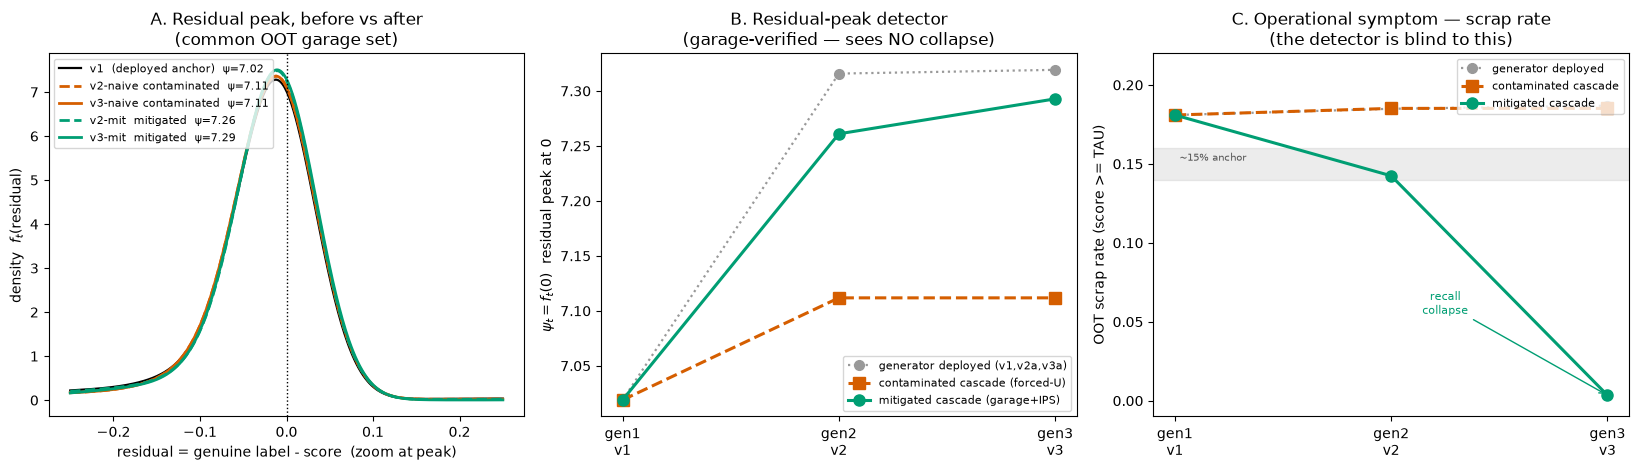

In [11]:
# ---- Figure: residual peak (before vs after) + the collapse the detector is blind to ----
# Built from the shared primitives in detector.report; panel layout / annotations stay here.
C_CONT, C_MIT, C_REF = "#D55E00", "#009E73", "#999999"   # Okabe-Ito CVD-safe pair + neutral ref
def scr(vals): return float((np.asarray(vals) >= TAU).mean())
p = cascade_report["peak0"]                              # ψ per version (from the table above)

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))

# A. residual PDF (zoom at the peak) — the requested before/after, drawn by the library
pdf = {k: og_scores[k] for k in ["v1  (deployed anchor)", "v2-naive contaminated",
       "v3-naive contaminated", "v2-mit  mitigated", "v3-mit  mitigated"]}
pdf_styles = {
    "v1  (deployed anchor)":   {"color": "k",     "lw": 1.6},
    "v2-naive contaminated":   {"color": C_CONT,  "lw": 2, "ls": "--"},
    "v3-naive contaminated":   {"color": C_CONT,  "lw": 2, "ls": "-"},
    "v2-mit  mitigated":       {"color": C_MIT,   "lw": 2, "ls": "--"},
    "v3-mit  mitigated":       {"color": C_MIT,   "lw": 2, "ls": "-"},
}
plot_residual_pdf(pdf, y_true, ax=ax[0], styles=pdf_styles)
ax[0].set_xlabel("residual = genuine label - score  (zoom at peak)")
ax[0].set_title("A. Residual peak, before vs after\n(common OOT garage set)")
ax[0].legend(fontsize=8, loc="upper left")

# B. ψ_t detector trajectory across generations
tri = lambda a, b, d: [p[a], p[b], p[d]]
xt = ["gen1\nv1", "gen2\nv2", "gen3\nv3"]
traj_styles = {"generator deployed (v1,v2a,v3a)": {"color": C_REF, "ls": ":", "marker": "o", "ms": 7, "lw": 1.6},
               "contaminated cascade (forced-U)": {"color": C_CONT, "ls": "--", "marker": "s", "lw": 2.2},
               "mitigated cascade (garage+IPS)":  {"color": C_MIT, "ls": "-", "marker": "o", "lw": 2.2}}
plot_metric_trajectory({
    "generator deployed (v1,v2a,v3a)": tri("v1  (deployed anchor)", "v2a generator (deployed)", "v3a generator (deployed)"),
    "contaminated cascade (forced-U)": tri("v1  (deployed anchor)", "v2-naive contaminated", "v3-naive contaminated"),
    "mitigated cascade (garage+IPS)":  tri("v1  (deployed anchor)", "v2-mit  mitigated", "v3-mit  mitigated"),
}, ax=ax[1], xticklabels=xt, ylabel=r"$\psi_t = f_t(0)$  residual peak at 0",
   title="B. Residual-peak detector\n(garage-verified — sees NO collapse)", styles=traj_styles)
ax[1].legend(fontsize=8, loc="lower right")

# C. scrap-rate trajectory — what the detector is structurally blind to
sc_gen = [scr(log.loc[oot_mask, col].values) for col in ["model_v1_score", "model_v2a_score", "model_v3a_score"]]
plot_metric_trajectory({
    "generator deployed":   sc_gen,
    "contaminated cascade": [sc_gen[0], scrap_rate(clf_naive), scrap_rate(clf_v3naive)],
    "mitigated cascade":    [sc_gen[0], scrap_rate(clf_v2mit), scrap_rate(clf_v3mit)],
}, ax=ax[2], xticklabels=xt, ylabel="OOT scrap rate (score >= TAU)",
   title="C. Operational symptom — scrap rate\n(the detector is blind to this)",
   band=(0.14, 0.16, {"color": C_REF}),
   styles={"generator deployed":   {"color": C_REF, "ls": ":", "marker": "o", "ms": 7, "lw": 1.6},
           "contaminated cascade": {"color": C_CONT, "ls": "--", "marker": "s", "lw": 2.2},
           "mitigated cascade":    {"color": C_MIT, "ls": "-", "marker": "o", "lw": 2.2}})
ax[2].text(0.02, 0.152, "~15% anchor", fontsize=7, color="#555")
ax[2].annotate("recall\ncollapse", xy=(2, scrap_rate(clf_v3mit)), xytext=(1.25, 0.055), fontsize=8,
               color=C_MIT, ha="center", arrowprops=dict(arrowstyle="->", color=C_MIT))
ax[2].set_ylim(-0.01, 0.22); ax[2].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("03_02_cascade_reeval.png", dpi=130, bbox_inches="tight")
plt.show()

### Reading the cascade re-evaluation

**The residual-peak detector alone does *not* certify the mitigation — and that is the finding.**

- **Panel A / B (ψ_t).** On the garage-verified set the residual peak barely moves and, if anything,
  the mitigated cascade reads a *higher* ψ_t than the contaminated one (≈ 7.29 vs ≈ 7.11). That is not
  a loop getting worse — it is the garage-only model being *better calibrated on the garage
  subpopulation* (it predicts ≈ 0 on the mostly-repairable garage rows, piling residuals at 0). The
  detector's window is exactly the low-score region both models handle well, so it is **structurally
  insensitive** to the fix.

- **Panel C (scrap rate).** The same mitigated cascade that looks "fine" to the detector **collapses**:
  scrap rate falls v2-mit ≈ 14% → v3-mit ≈ **0%**. Garage-only training never sees the high-score
  region (cell ① ≈ empty; positivity fails), so each generation strips more of the total-loss signal
  until gen 3 scraps almost nothing — the exact **recall collapse that shelved the real v3**, now
  reproduced from first principles by the cascade.

**Conclusion for the framework.** Residual-peak ψ_t is *necessary* (it is the only oracle-free loop
signal) but *not sufficient* to declare a mitigation successful. It must be read **together with the
scrap-rate trajectory** against the ~15% anchor: a fix is only credible if ψ_t stabilises **and** the
scrap rate holds near the anchor without collapsing. The garage-verified blind spot — the same
positivity limit flagged in Step 1 — is why the operational panel, not the detector, is what catches
the failure. This motivates **Step 2** (bringing U back with a trust-weighted floor) as the route to a
cascade-stable fix rather than a collapsing one.

> **Caveat.** These are single-realisation synthetic numbers on a low-positivity garage slice; the
> gen-3 collapse magnitude will vary with seed and window. The **qualitative** result — detector blind,
> scrap rate collapses — is the transferable point, and it is what to re-check on real Allianz data.